# Coding Tutorial - Bayesian Workflow using PyMC

**Yichen Ji**

2026-07-17, STATSTRO

The material is inspired by some awesome resources on Bayesian astrostats and workflow:

* [Practical Guidance for Bayesian Inference in Astronomy](https://arxiv.org/abs/2302.04703) (co-authored by Gwen and Josh)
* [Practical Bayesian Inference in Astronomy](https://astrowizici.st/teaching/data-analysis/workflow_model_building/lecture-04/) by Andy Casey
* [Recently published textbook on Bayesian workflow](https://avehtari.github.io/Bayesian-Workflow/) by Gelman et al.
* [Towards A Principled Bayesian Workflow](https://betanalpha.github.io/assets/case_studies/principled_bayesian_workflow.html) by Michael Betancourt



## Set the tone

Q: What is a workflow?

Wiki: A sequence of orchestrated and repeatable steps, serving as a roadmap for getting work done efficiently.


---


Q: What is a Bayesian workflow?

TL;DR: An iterative process of building, fitting, checking, and revising a Bayesian model.



---


Q: What does a Bayesian workflow (mainly) consist of?

Specify a model $\rightarrow$ Prior predictive checks $\rightarrow$ Fitting the model $\rightarrow$ Computation checks $\rightarrow$ Posterior predictive checks $\rightarrow$ Calibration and robustness checks $\rightarrow$ Model evaluation, selection, comparison $\rightarrow$ Revise the model and loop over

---

My 2 cents: Practitioners (like yourself!) already do those steps here and there in different hats (prior elicitation, convergence diagnostics, sensitivity analysis, etc.)! Rather than treating the Bayesian workflow as a new set of statistical techniques, it makes more sense to think of it as making tacit knowledge about applied Bayesian modeling in an explicit, principled, and systematic way.

### Notation

$$
\begin{array}{|l|l|l|}
\hline
\text{Symbol} & \text{Name} & \text{Meaning} \\
\hline
\theta & \text{Parameters} & \text{Setting that controls how things work} \\
\hline
y & \text{Data} & \text{Observed values} \\
\hline
\tilde{y} & \text{Replicated data} &
\text{New data drawn from the predictive distribution} \\
\hline
p(\theta) & \text{Prior} &
\text{Parameter model before observing data} \\
\hline
p(y \mid \theta) & \text{Likelihood} &
\text{Data model given parameters} \\
\hline
p(\theta \mid y) & \text{Posterior} &
\text{Updated parameter model after observing data} \\
\hline
p(\tilde{y}) & \text{Prior predictive} & \text{Distribution of replicated or future data before seeing the observed data} \\
\hline
p(\tilde{y} \mid y) & \text{Posterior predictive} &
\text{Distribution of replicated or future data given observed data} \\
\hline
\end{array}
$$

# Example: Gamma-Ray Burst Afterglows

## Context:

(Very) toy example, but good enough to demonstrate the concepts:)

These are 63 Swift XRT measurements from **one** afterglow, GRB 050525A ([Data source](https://sites.psu.edu/astrostatistics/datasets-grb-afterglow/)). The columns in the dataset are:



*   X-ray flux (in units of 10-11 erg/cm2/s,
*   time of observation (in seconds)2-10 keV)
*   measurement error of the flux based on detector signal-to-noise values


Most models are based on linear regression in the logrithmic variables giving decay laws of the form

$$
Flux \sim Time^{\beta} \\
log(Flux) \sim \beta * log(Time)
$$ where beta<0.

According to [Blustin et al.](http://arxiv.org/abs/astro-ph/0507515), the early afterglow decay was first fitted with a **single power-law model**. A better fit is provided by a **broken power law model** with slopes $\beta_1$, $\beta_2$ and a break at $t_b$.


**Scientific question:** Can the fading X-ray afterglow be described by a single power law, or does its decay rate change over time?



## 0. Setup

In [15]:
%pip install -q "nutpie[pymc]" arviz pandas matplotlib scipy


In [ ]:
import os
import platform
from pathlib import Path
from time import perf_counter
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
# a fast NUTS sampler for PyMC and Stan models
import nutpie
# visualization
import arviz as az
import scipy

print(f"Python {platform.python_version()}")
print(f"PyMC {pm.__version__}")
print(f"nutpie {nutpie.__version__}")
print(f"ArviZ {az.__version__}")
print(f"NumPy {np.__version__}")
print(f"pandas {pd.__version__}")


Python 3.12.13
PyMC 5.28.5
nutpie 0.16.11
ArviZ 0.23.4
NumPy 2.0.2
pandas 2.2.2


In [17]:
DATA_URL = "/content/drive/MyDrive"
LOCAL_DATA_PATH = "GRB_afterglow.dat"

SBC_CACHE_URL = "REPLACE_WITH_SBC_CACHE_URL"
SBC_CACHE_PATH = "sbc_single_power_law.csv"

SEED = 20260717
FAST_MODE = False
RUN_SBC = True

rng = np.random.default_rng(SEED)
cores = min(4, os.cpu_count() or 1)
if FAST_MODE:
    draws, tune = 500, 500
else:
    draws, tune = 5000, 5000

plt.rcParams.update({
    "figure.figsize": (8.5, 5.2),
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
})
print(f"CPU cores used: {cores}; posterior draws/tune per chain: {draws}/{tune}")


CPU cores used: 2; posterior draws/tune per chain: 5000/5000


## 1. Load and EDA

In Colab, upload `GRB_afterglow.dat` into the session before running this cell.


In [18]:
ALIASES = {
    "time_s": {"time_s", "time", "t"},
    "flux": {"flux", "f"},
    "flux_err": {"flux_err", "flux_error", "sigma_flux", "error", "err", "s"},
}


def _read_afterglow_table(source) -> pd.DataFrame:
    """Read a CSV-like file or the Penn State whitespace table."""
    try:
        frame = pd.read_csv(source, sep=None, engine="python")
    except Exception:
        frame = pd.DataFrame()
    parsed_names = {str(c).strip().lower() for c in frame.columns}
    recognized = sum(bool(parsed_names & candidates) for candidates in ALIASES.values())
    if recognized < 3:
        # The supplied .dat file has a prose title on line 1, then `t f s`.
        frame = pd.read_csv(source, sep=r"\s+", skiprows=1)
    return frame


def load_afterglow(local_path: str, data_url: str) -> pd.DataFrame:
    """Data loader."""
    path = Path(local_path)
    if path.exists():
        raw = _read_afterglow_table(path)
        source_used = str(path)
    elif not data_url.startswith("REPLACE_WITH_"):
        try:
            raw = _read_afterglow_table(data_url)
            source_used = data_url
        except Exception as exc:
            raise FileNotFoundError(
                f"Could not read {data_url!r}. Upload {local_path!r} to the Colab "
                "Files pane (folder icon), then rerun this cell."
            ) from exc
    else:
        raise FileNotFoundError(
            f"Dataset not found at {local_path!r}. Upload GRB_afterglow.dat to the "
            "Colab Files pane, or replace DATA_URL with a direct download URL. "
            "No substitute dataset will be generated."
        )

    print("Data source:", source_used)
    print("Original column names:", list(raw.columns))
    normalized = {str(c).strip().lower(): c for c in raw.columns}
    rename = {}
    for target, candidates in ALIASES.items():
        match = next((normalized[c] for c in candidates if c in normalized), None)
        if match is not None:
            rename[match] = target
    cleaned = raw.rename(columns=rename)
    missing = [name for name in ALIASES if name not in cleaned.columns]
    if missing:
        raise ValueError(
            f"Missing required variable(s): {missing}. Available columns: {list(raw.columns)}"
        )
    cleaned = cleaned[["time_s", "flux", "flux_err"]].apply(pd.to_numeric, errors="coerce")
    valid = (
        np.isfinite(cleaned).all(axis=1)
        & (cleaned["time_s"] > 0)
        & (cleaned["flux"] > 0)
        & (cleaned["flux_err"] > 0)
    )
    n_removed = int((~valid).sum())
    cleaned = cleaned.loc[valid].sort_values("time_s").reset_index(drop=True)
    print(f"Removed {n_removed} invalid observations; {len(cleaned)} remain.")
    if cleaned.empty:
        raise ValueError("No valid observations remain after validation.")
    return cleaned


data = load_afterglow(LOCAL_DATA_PATH, DATA_URL)
display(data.head(8))


Data source: GRB_afterglow.dat
Original column names: ['t', 'f', 's']
Removed 0 invalid observations; 63 remain.


,time_s,flux,flux_err
0,133,122.7,5.7
1,143,109.5,5.4
2,153,101.4,5.2
3,163,92.0,4.9
4,173,86.8,4.8
5,183,83.7,4.7
6,193,77.2,4.5
7,203,69.4,4.3


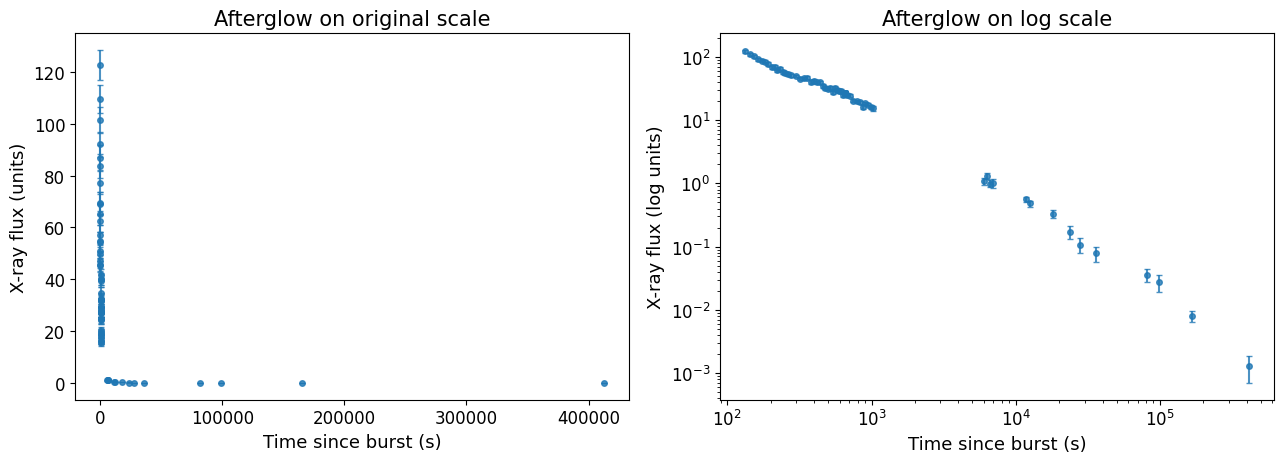

In [19]:
# plot data in both original and log scale
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax in axes:
    ax.errorbar(
        data["time_s"], data["flux"], yerr=data["flux_err"],
        fmt="o", ms=4, alpha=0.8, capsize=2, label="GRB 050525A",
    )
    ax.set_xlabel("Time since burst (s)")
axes[0].set_title("Afterglow on original scale")
axes[1].set_title("Afterglow on log scale")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[0].set_ylabel("X-ray flux (units)")
axes[1].set_ylabel("X-ray flux (log units)")
fig.tight_layout()
plt.show()


A power law becomes a straight line after taking logs, which can be parameterized as follows:

$$F(t)=A(t/t_0)^\beta,\qquad \log F(t)=\log A+\beta\log(t/t_0).$$

Denote $x_i=\log(t_i/t_0)$, $y_i=\log F(t_i)$. Note that $A = F(t_0)$ represents the flux at a typical observed time, and we use $t_0$ as the reference/pivot time to be the geometric-mean $t_0=\exp[n^{-1}\sum_i\log t_i]$ for modeling convenience.


We also need to transform the measurement error to the log scale, which can be approximated by $s_{y,i}\approx s_{F,i}/F_i$, provided that the flux uncertainty is small relative to the measured flux. This trick is based on the fact that

$$
\frac{d \log F}{d F}=\frac{1}{F}
$$

In [20]:
time_s = data["time_s"].to_numpy(float)
flux = data["flux"].to_numpy(float)
flux_err = data["flux_err"].to_numpy(float)
T0 = float(np.exp(np.mean(np.log(time_s))))
x = np.log(time_s / T0)
y = np.log(flux)
y_err = flux_err / flux
INTERCEPT_PRIOR_MEAN = float(np.median(y))

range_table = pd.DataFrame({
    "quantity": ["time (s)", "flux (units)", "log time", "relative flux uncertainty"],
    "minimum": [time_s.min(), flux.min(), np.log(time_s).min(), y_err.min()],
    "maximum": [time_s.max(), flux.max(), np.log(time_s).max(), y_err.max()],
})
print(f"Geometric-mean pivot t0 = {T0:.3g} s")
display(range_table)


Geometric-mean pivot t0 = 1.05e+03 s


,quantity,minimum,maximum
0,time (s),133.000000,412515.000000
1,flux (units),0.001300,122.700000
2,log time,4.890349,12.930028
3,relative flux uncertainty,0.046455,0.461538


## 2. Build Model 1 — a single power-law decay

We now embed this deterministic physical relationship in a probabilistic model by treating the power law as the expected signal and explicitly modeling measurement noise and parameter uncertainty.

$$
\begin{aligned}
a&\sim N(m_a,2^2), & \beta&\sim N(-1,0.75^2),\\
\sigma_{\rm int}&\sim\operatorname{HalfNormal}(0.5), &
\mu_i&=a+\beta x_i,\\
y_i&\sim N\!\left(\mu_i,s_{y,i}^2+\sigma_{\rm int}^2\right).
\end{aligned}
$$

Here $a=\log A$ is expected log flux at the reference time, $\beta$ is the decay index, and $\sigma_{\rm int}$ captures variation beyond reported measurement error. Centering $a$ at the sample median of log flux only puts the intercept on the observed numerical scale; it does not fit the slope or break.


In [21]:
def _build_single_power_law_model(
    x: np.ndarray,
    y: np.ndarray | None,
    y_err: np.ndarray,
    intercept_prior_mean: float,
) -> pm.Model:
    coords = {"obs_id": np.arange(len(x))}

    ######################### PyMC model #########################
    with pm.Model(coords=coords) as model:
        # 1. create data containers that registers data variables
        x_data = pm.Data("x", np.asarray(x), dims="obs_id")
        y_err_data = pm.Data("y_err", np.asarray(y_err), dims="obs_id")
        # 2. define priors
        a = pm.Normal("a", mu=intercept_prior_mean, sigma=2.0)
        beta = pm.Normal("beta", mu=-1.0, sigma=0.75)
        sigma_int = pm.HalfNormal("sigma_int", sigma=0.5)
        # deterministic transformations for the mean and total standard deviation of the likelihood
        # they don't add randomness in the model, used to record an intermediate quantity for convenience
        mu = pm.Deterministic("mu", a + beta * x_data, dims="obs_id")
        sigma_total = pm.Deterministic(
            "sigma_total", pm.math.sqrt(y_err_data**2 + sigma_int**2), dims="obs_id"
        )
        # 3. define likelihood
        pm.Normal("y_obs", mu=mu, sigma=sigma_total, observed=y, dims="obs_id")
    return model


def build_single_power_law_model(
    x: np.ndarray,
    y: np.ndarray | None,
    y_err: np.ndarray,
) -> pm.Model:
    return _build_single_power_law_model(x, y, y_err, INTERCEPT_PRIOR_MEAN)


single_model = build_single_power_law_model(x, y, y_err)
single_model


## 3. Prior predictive checks

Prior predictive distribution:

$$
p(\tilde{y}) = \int p(\tilde{y} \mid \theta) p(\theta) d \theta
$$

Prior predictive checks are tools for comparing our model assumptions to our domain expertise (range, shape, trend constraints), and **only** to our domain expertise, which should be evaluated in **observation data space**, not parameter space.

How does it operationally work?



1.   Sample from the prior $\theta^{(s)} \sim p(\theta)$ ;
2.   Simulate data $\tilde{y^{(s)}} \sim p(y \mid \theta^{(s)})$ from the likelihood;
3.   Compare simulated data with scientifically plausible constraints and summary statistics.
4.   Revise priors if simulated data are implausible, then repeat.


Ask yourself: With this set of priors and data-generating process (likelihood), do the simulated data **look like** the real observations at hand?

*   What aspects of being "look like"? Summary statistics of interest, trajectories, etc.
*   As long the real data is within the cloud/histogram of the simulated prior predictive data, we are good.



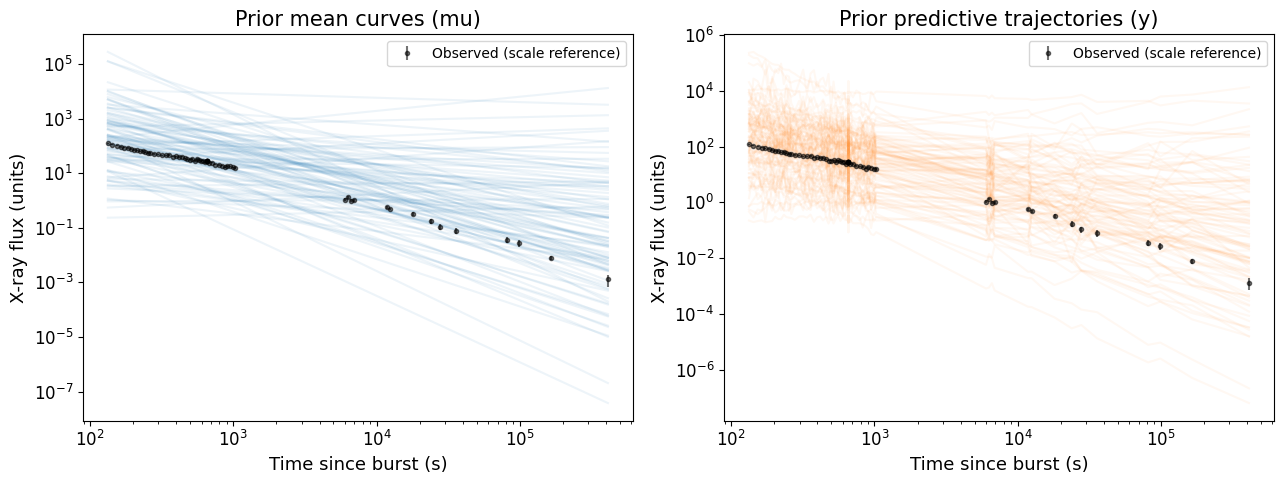

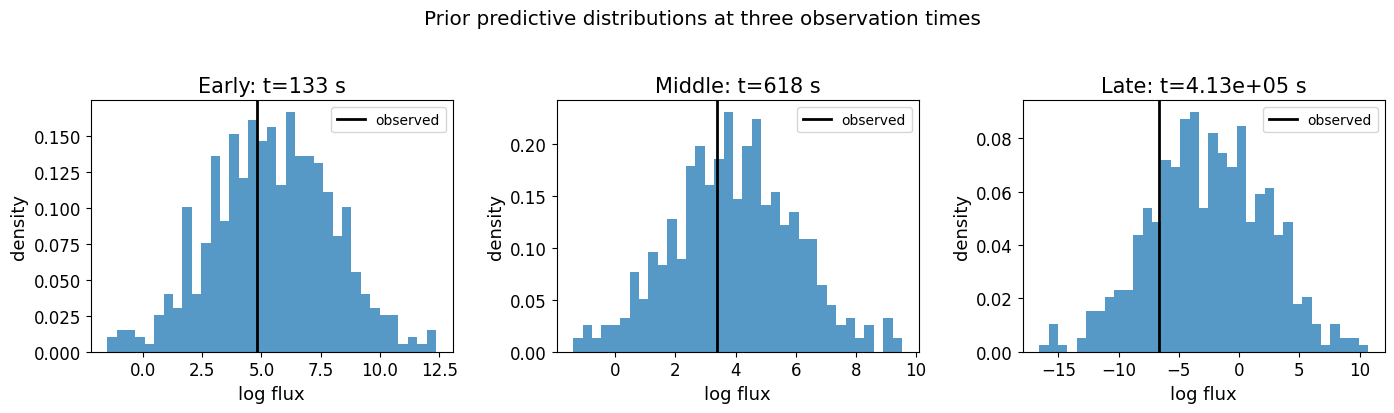

In [22]:
# build model
prior_model = build_single_power_law_model(x, None, y_err)

# prior predictive checks in one line
with prior_model:
    prior_single = pm.sample_prior_predictive(draws=500, random_seed=SEED)

prior_mu = prior_single.prior["mu"].stack(sample=("chain", "draw")).transpose("sample", "obs_id").values
prior_y = prior_single.prior["y_obs"].stack(sample=("chain", "draw")).transpose("sample", "obs_id").values
curve_ids = rng.choice(prior_mu.shape[0], size=100, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for j in curve_ids:
    axes[0].plot(time_s, np.exp(prior_mu[j]), color="C0", alpha=0.08)
    axes[1].plot(time_s, np.exp(np.clip(prior_y[j], -700, 700)), color="C1", alpha=0.05)
for ax in axes:
    ax.errorbar(time_s, flux, yerr=flux_err, fmt="o", ms=3, color="black", alpha=0.55, label="Observed (scale reference)")
    ax.set(xscale="log", yscale="log", xlabel="Time since burst (s)", ylabel="X-ray flux (units)")
    ax.legend()
axes[0].set_title("Prior mean curves (mu)")
axes[1].set_title("Prior predictive trajectories (y)")
fig.tight_layout()
plt.show()

idx = [0, len(x) // 2, len(x) - 1]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, i, label in zip(axes, idx, ["early", "middle", "late"]):
    vals = prior_y[:, i]
    ax.hist(vals, bins=35, density=True, alpha=0.75)
    ax.axvline(y[i], color="black", lw=2, label="observed")
    ax.set(title=f"{label.title()}: t={time_s[i]:.3g} s", xlabel="log flux", ylabel="density")
    ax.legend()
fig.suptitle("Prior predictive distributions at three observation times", y=1.03)
fig.tight_layout()
plt.show()


Conclusions:

- The prior predictive draws cover the observed fluxes and allow the expected overall decay, so the priors do not rule out plausible data before fitting.
- However, the wider spread in later time since burst and occasional flat or rising trajectories (in orange) suggest that the priors are weak/broad and could be tightened if such behavior is physically implausible.
- The observed summary statistics all fall within the bulk of the corresponding prior predictive distributions. The very wide late-time distribution (ranging between -15 and 10) indicates that the priors allow substantial uncertainty in long-term decay.


What if we use a VERY diffuse prior setting?

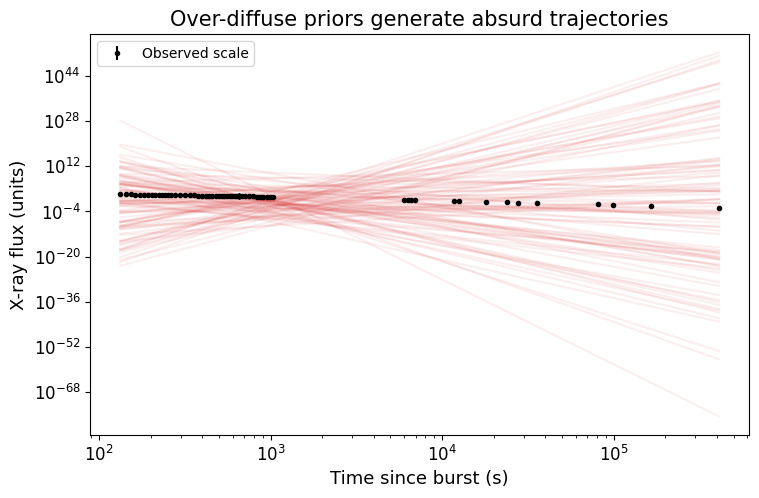

log10 predicted-flux range: -76.7500786601215 to 52.425694077947256


In [23]:
# Intentionally over-diffuse example — simulate from prior predictive distribution (in red)

# number of draws to simulate
n_bad = 100
# diffuse priors
a_bad = rng.normal(0, 10, n_bad)
beta_bad = rng.normal(0, 10, n_bad)
# calculate mu as the mean of the likelihood
mu_bad = a_bad[:, None] + beta_bad[:, None] * x[None, :]

# plot the prior predictive trajectories
fig, ax = plt.subplots()
for row in mu_bad:
    ax.plot(time_s, np.exp(np.clip(row, -700, 700)), color="C3", alpha=0.08)
ax.errorbar(time_s, flux, yerr=flux_err, fmt="o", ms=3, color="black", label="Observed scale")
ax.set(xscale="log", yscale="log", xlabel="Time since burst (s)",
       ylabel="X-ray flux (units)", title="Over-diffuse priors generate absurd trajectories")
ax.legend()
plt.show()
print("log10 predicted-flux range:", np.nanmin(mu_bad / np.log(10)), "to", np.nanmax(mu_bad / np.log(10)))


The deliberately diffuse $a\sim\mathcal N(0,10^2)$, $\beta\sim\mathcal N(0,10^2)$ example can imply explosive increases and many orders of magnitude. “Weakly informative” is meaningful only after checking predictions on the observable scale.


## 4. Simulation-based calibration (SBC)

General idea:

- A Bayesian posterior is calibrated if, across repeated datasets generated from the assumed model, the posterior intervals have appropriate empirical coverage to the nominal level, e.g., 80% intervals are expected to contain the true parameter 80% of the time.
- However, the true parameter is unknown for real data; all we have is one dataset and an approximate posterior represented as a bunch of samples, so posterior coverage cannot be directly evaluated.
- However, we can construct parameter ground truth by simulation, and generate synthetic datasets with these known parameter values.
- If inference is calibrated, the "true" parameters should be indistinguishable from the posterior draws across repeated simulations, which can be assessed by the uniformity of rank histograms.


How does it operationally work?

1. Draw parameter samples from the prior $\tilde{\theta} \sim p(\theta)$;
2. Draw simulated dataset from this ground truth $\tilde{y} \sim p(y \mid \tilde{\theta})$;
3. Repeating Steps 1 and 2 $N$ times produces N simulated parameter-data pairs $\{(\tilde{\theta}^{(n)}, \tilde{y}^{(n)})\}_{n=1}^N$.
4. For each simulated dataset n, fit the model using the sampler to be checked, and obtain $M$ posterior draws $\theta^{(n, 1)}, \ldots, \theta^{(n, M)} \sim p\left(\theta \mid \tilde{y}^{(n)}\right)$
5. Compute the rank of the "ground truth" $\tilde{\theta}^{(n)}$ among $M$ posterior draws.
6. If calibrated, the distribution of those $N$ ranks should be uniform over $0,...,M$ ;
    - each rank leverages the exchangeability of $\{\theta_1,...,\theta_M, \tilde{\theta}\}$
    - equivalently, posterior credible intervals should attain their nominal empirical coverage across the N simulations.

SBC can be viewed as a necessary condition (but not sufficient) for a valid inference algorithm (aka the sampler we use):
- If SBC checks fail, this tells you that your inference is invalid.
- If SBC checks pass, this is NO guarantee that the posterior estimation is working.
- In other words, SBC is a self-consistency check: it can tell us we are not wrong, but it cannot tell us whether we are right.

Some good tutorial posts on SBC:

- [Stan documentation](https://mc-stan.org/docs/stan-users-guide/simulation-based-calibration.html)
- [SBI package documentation](https://sbi.readthedocs.io/en/stable/advanced_tutorials/11_diagnostics_simulation_based_calibration.html)

In [24]:
def simulate_single_power_law(
    x: np.ndarray,
    y_err: np.ndarray,
    intercept_prior_mean: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, dict[str, float]]:
    """
    One simulated dataset from the single power-law model, along with the true parameter values.
    """
    truth = {
        "a": float(rng.normal(intercept_prior_mean, 2.0)),
        "beta": float(rng.normal(-1.0, 0.75)),
        "sigma_int": float(abs(rng.normal(0.0, 0.5))),
    }
    mu = truth["a"] + truth["beta"] * x
    sigma = np.sqrt(y_err**2 + truth["sigma_int"]**2)
    return rng.normal(mu, sigma), truth


def fit_single_power_law_for_sbc(
    x: np.ndarray,
    y: np.ndarray,
    y_err: np.ndarray,
    intercept_prior_mean: float,
    seed: int,
    draws: int,
    tune: int,
) -> az.InferenceData:
    """
    Fit the single power-law model to a simulated dataset for SBC, returning the posterior samples.
    """
    model = _build_single_power_law_model(x, y, y_err, intercept_prior_mean)
    with model:
        return pm.sample(
            draws=draws, tune=tune, chains=1, cores=1,
            nuts_sampler="nutpie", backend="numba",
            nuts={"target_accept": 0.9}, random_seed=seed,
            progressbar=False, compute_convergence_checks=False,
        )


def compute_sbc_rank(
    posterior_samples: np.ndarray,
    true_value: float,
    rng: np.random.Generator,
) -> int:
    """
    Compute the rank of the true parameter value among the posterior samples for SBC.
    """
    samples = np.asarray(posterior_samples).ravel()
    n_less = int(np.sum(samples < true_value))
    n_equal = int(np.sum(samples == true_value))
    return n_less + int(rng.integers(0, n_equal + 1))


def run_sbc(
    x: np.ndarray,
    y_err: np.ndarray,
    intercept_prior_mean: float,
    n_replicates: int,
    draws: int,
    tune: int,
    seed: int,
) -> pd.DataFrame:
    """
    Full SBC steps: simulate datasets, fit the model, and compute ranks for each parameter. Returns a DataFrame with the results.
    """
    local_rng = np.random.default_rng(seed)
    rows = []
    for rep in range(n_replicates):
        # 1. generate a simulated data-parameter pair
        y_sim, truth = simulate_single_power_law(x, y_err, intercept_prior_mean, local_rng)

        # 2. fit the model to the simulated data
        fit_seed = int(local_rng.integers(1, 2**31 - 1))
        fit = fit_single_power_law_for_sbc(x, y_sim, y_err, intercept_prior_mean, fit_seed, draws, tune)

        # 3. for each parameter, compute the rank of the true value among the posterior samples
        for parameter, true_value in truth.items():
            samples = fit.posterior[parameter].values.ravel()
            rank = compute_sbc_rank(samples, true_value, local_rng)
            rows.append({
                "replication": rep, "parameter": parameter, "true_value": true_value,
                "rank": rank, "n_draws": samples.size,
                "fractional_rank": (rank + 0.5) / (samples.size + 1),
            })
        print(f"SBC replication {rep + 1}/{n_replicates} complete")
    return pd.DataFrame(rows)


In [25]:
if FAST_MODE:
    n_sbc_replicates, sbc_draws, sbc_tune = 10, 250, 250
else:
    n_sbc_replicates, sbc_draws, sbc_tune = 50, 1000, 1000

cache_path = Path(SBC_CACHE_PATH)
if RUN_SBC:
    sbc_results = run_sbc(x, y_err, INTERCEPT_PRIOR_MEAN,
                        n_sbc_replicates, sbc_draws, sbc_tune, SEED + 100)
    sbc_results.to_csv(cache_path, index=False)
    sbc_label = f"{n_sbc_replicates} requested replications"
elif cache_path.exists():
    sbc_results = pd.read_csv(cache_path)
    sbc_label = f"cached results ({sbc_results.replication.nunique()} replications)"
elif not SBC_CACHE_URL.startswith("REPLACE_WITH_"):
    sbc_results = pd.read_csv(SBC_CACHE_URL)
    sbc_label = f"downloaded cache ({sbc_results.replication.nunique()} replications)"
else:
    print("No SBC cache is available: running five minimal illustrative replications.")
    sbc_results = run_sbc(x, y_err, INTERCEPT_PRIOR_MEAN, 5, 100, 100, SEED + 100)
    sbc_results.to_csv(cache_path, index=False)
    sbc_label = "five-replication illustration — not convincing calibration evidence"

print(sbc_label)
display(sbc_results.head())


SBC replication 1/50 complete
SBC replication 2/50 complete
SBC replication 3/50 complete
SBC replication 4/50 complete
SBC replication 5/50 complete
SBC replication 6/50 complete
SBC replication 7/50 complete
SBC replication 8/50 complete
SBC replication 9/50 complete
SBC replication 10/50 complete
SBC replication 11/50 complete
SBC replication 12/50 complete
SBC replication 13/50 complete
SBC replication 14/50 complete
SBC replication 15/50 complete
SBC replication 16/50 complete
SBC replication 17/50 complete
SBC replication 18/50 complete
SBC replication 19/50 complete
SBC replication 20/50 complete
SBC replication 21/50 complete
SBC replication 22/50 complete
SBC replication 23/50 complete
SBC replication 24/50 complete
SBC replication 25/50 complete
SBC replication 26/50 complete
SBC replication 27/50 complete
SBC replication 28/50 complete
SBC replication 29/50 complete
SBC replication 30/50 complete
SBC replication 31/50 complete
SBC replication 32/50 complete
SBC replication 3

,replication,parameter,true_value,rank,n_draws,fractional_rank
0,0,a,1.353037,775,1000,0.774725
1,0,beta,0.123440,687,1000,0.686813
2,0,sigma_int,0.038965,486,1000,0.486014
3,1,a,3.923272,533,1000,0.532967
4,1,beta,-0.727524,375,1000,0.375125


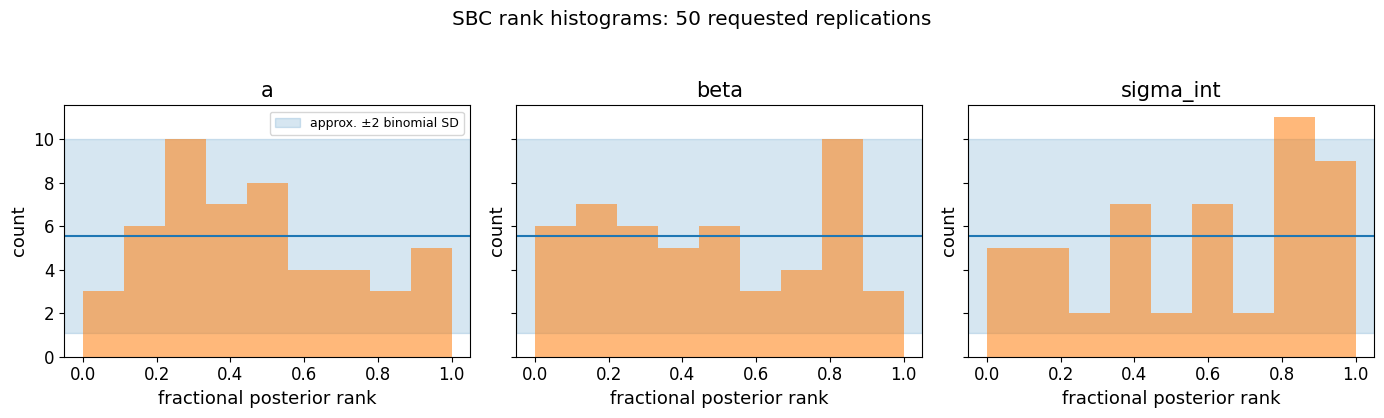

In [26]:
parameters = ["a", "beta", "sigma_int"]
bins = np.linspace(0, 1, 10)
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, parameter in zip(axes, parameters):
    ranks = sbc_results.loc[sbc_results.parameter == parameter, "fractional_rank"].to_numpy()
    counts, edges = np.histogram(ranks, bins=bins)
    p = 1 / (len(edges) - 1)
    expected = len(ranks) * p
    sd = np.sqrt(len(ranks) * p * (1 - p))
    ax.axhspan(max(0, expected - 2 * sd), expected + 2 * sd,
               color="C0", alpha=0.18, label="approx. ±2 binomial SD")
    ax.stairs(counts, edges, fill=True, alpha=0.55, color="C1")
    ax.axhline(expected, color="C0", lw=1.5)
    ax.set(title=parameter, xlabel="fractional posterior rank", ylabel="count")
axes[0].legend(fontsize=9)
fig.suptitle(f"SBC rank histograms: {sbc_label}", y=1.04)
fig.tight_layout()
plt.show()


Inspection cases:
- U-shaped ranks can indicate posterior underdispersion (too narrow posterior, too short credible interval, underestimate uncertainty);
- Inverted-U ranks can indicate overdispersion (too wide posterior, too broad credible interval, overestimate uncertainty);
- Skew can indicate bias;
- Approximate uniformity is consistent with calibration.



## 5. Fit Model 1 with nutpie on CPU

People usually close their eyes and click the sampling button. To those who want to know the bottom details: PyMC separates **model specification**, **numerical computation**, and **sampling**:

$$
\text{PyMC model}
\;\longrightarrow\;
\text{computational backend}
\;\longrightarrow\;
\text{NUTS implementation}
\;\longrightarrow\;
\text{posterior draws}.
$$

- **PyMC** specifies the probabilistic model through a `PyTensor` computational graph.
- The **computational backend** determines how the log posterior and its gradient are evaluated, using numerical computing systems such as `PyTensor`, `Numba`, or `JAX`, to accelerate graph execution on CPUs and GPUs.
- **PyMC** can employ alternative sampler implementations, such as `nutpie`, `NumPyro`, and `BlackJAX`, to use these evaluations to generate posterior draws.

In this tutorial, we use `nutpie` as the default NUTS implementation; changing the sampler should not change the target posterior, but may affect compilation time, sampling speed, diagnostics, and hardware support.

In [27]:
# build model
single_model = build_single_power_law_model(x, y, y_err)
start = perf_counter()

# sample from the posterior using nutpie with numba backend
with single_model:
    idata_single = pm.sample(
        draws=draws, tune=tune, chains=4, cores=cores,
        nuts_sampler="nutpie", backend="numba",
        nuts={"target_accept": 0.95}, random_seed=SEED,
    )
    # compute log-likelihood
    pm.compute_log_likelihood(idata_single, extend_inferencedata=True)
elapsed_single = perf_counter() - start

print(f"Elapsed sampling time: {elapsed_single:.1f} s")
print(f"Chains: {idata_single.posterior.sizes['chain']}; retained draws/chain: {idata_single.posterior.sizes['draw']}; tune/chain: {tune}")
display(az.summary(idata_single, var_names=["a", "beta", "sigma_int"], round_to=3))


Progress,Draws,Divergences,Step Size,Gradients/Draw
,10000,0,0.57,7
,10000,0,0.59,7
,10000,0,0.65,7
,10000,0,0.64,7


Output()

Elapsed sampling time: 10.1 s
Chains: 4; retained draws/chain: 5000; tune/chain: 5000


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,2.430,0.031,2.373,2.488,0.0,0.0,16492.467,13906.212,1.0
beta,-1.291,0.021,-1.330,-1.253,0.0,0.0,15956.480,14503.012,1.0
sigma_int,0.220,0.025,0.176,0.268,0.0,0.0,16272.604,13395.852,1.0


In [28]:
# summarize posterior samples from the log-scale parameters to the original scale
posterior_single = idata_single.posterior
idata_single.posterior = posterior_single.assign(
    A=np.exp(posterior_single["a"]),
    multiplicative_factor=np.exp(posterior_single["sigma_int"]), # multiplicative factor exp(\sigma_{int})
)
display(az.summary(
    idata_single,
    var_names=["A", "beta", "sigma_int", "multiplicative_factor"],
    kind="stats", round_to=3,
))
print("Interpretation: beta < 0 means declining flux; a more negative beta means faster decay.")


,mean,sd,hdi_3%,hdi_97%
A,11.370,0.352,10.725,12.043
beta,-1.291,0.021,-1.330,-1.253
sigma_int,0.220,0.025,0.176,0.268
multiplicative_factor,1.247,0.031,1.191,1.306


Interpretation: beta < 0 means declining flux; a more negative beta means faster decay.


## 6. Computational diagnostics

No divergences, $\widehat R$ near one (preferably below about 1.01), and adequate bulk/tail effective sample sizes (>100) are useful heuristics, not guarantees.

> **Computational diagnostics assess whether the sampler explored the specified posterior distribution. They do not assess whether the power-law model adequately describes the afterglow.**


In [29]:
diag_single = az.summary(
    idata_single, var_names=["a", "beta", "sigma_int"],
    kind="all", hdi_prob=0.94, round_to=3,
)
hdi_columns = [name for name in diag_single.columns if name.startswith("hdi")]
display(diag_single[["mean", "sd", *hdi_columns, "ess_bulk", "ess_tail", "r_hat"]])

divergences_single = int(idata_single.sample_stats["diverging"].sum().item())
print("Divergent transitions:", divergences_single)
print("Maximum R-hat:", float(diag_single["r_hat"].max()))
print("Minimum bulk ESS:", float(diag_single["ess_bulk"].min()))
print("Minimum tail ESS:", float(diag_single["ess_tail"].min()))
if divergences_single or diag_single["r_hat"].max() >= 1.01:
    print("WARNING: diagnostics merit investigation before interpreting summaries.")


,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
a,2.430,0.031,2.373,2.488,16492.467,13906.212,1.0
beta,-1.291,0.021,-1.330,-1.253,15956.480,14503.012,1.0
sigma_int,0.220,0.025,0.176,0.268,16272.604,13395.852,1.0


Divergent transitions: 0
Maximum R-hat: 1.0
Minimum bulk ESS: 15956.48
Minimum tail ESS: 13395.852


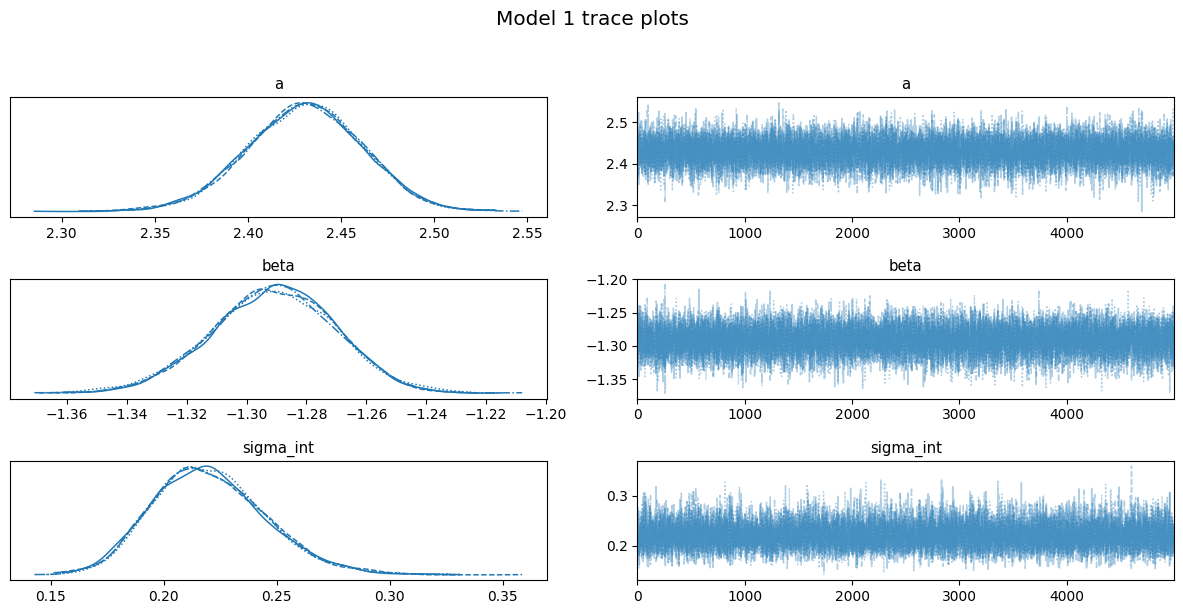

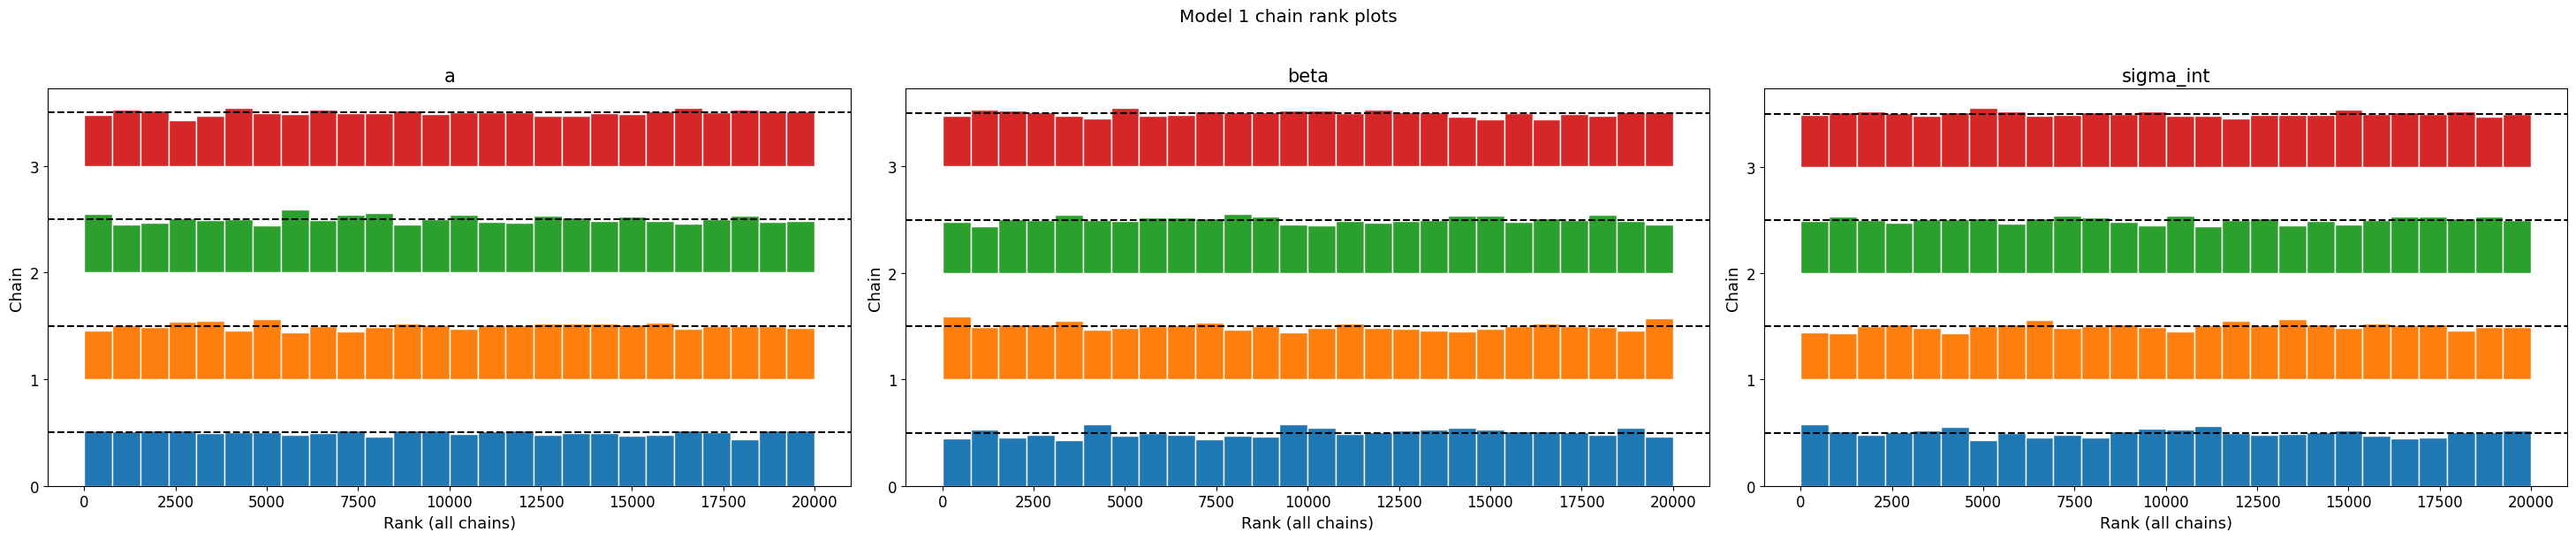

In [30]:
az.plot_trace(idata_single, var_names=["a", "beta", "sigma_int"])
plt.suptitle("Model 1 trace plots", y=1.02)
plt.tight_layout()
plt.show()

# rank plots: Good mixing means every chain contributes roughly uniformly across low, middle, and high ranks,
# so the chain-specific bars look similar and stay near the reference level.
az.plot_rank(idata_single, var_names=["a", "beta", "sigma_int"])
plt.suptitle("Model 1 chain rank plots", y=1.02)
plt.tight_layout()
plt.show()


## 7. Posterior predictive checks

Posterior predictive distribution:

$$
p(\tilde{y} \mid y) = \int p(\tilde{y} \mid \theta) p(\theta \mid y) d \theta
$$

- Examine the (in-sample) model fit to real data
- If the model is correctly specified, the real data should 'look like' draws from the posterior predictive distribution.

How does it operationally work (after fitting a model)?

1. Draw parameters from the posterior $\theta^{(s)} \sim p(\theta \mid y)$;
2. Simulate replicated datasets $\tilde{y}^{(s)} \sim p(y \mid \theta^{(s)})$;
3. Compare the replicated data with the observed data in some way, e.g., trajectory plots, histograms of summary statistics of interest;
4. Revise the likelihood or model structure if systematic discrepancies remain, then refit and repeat.

Output()

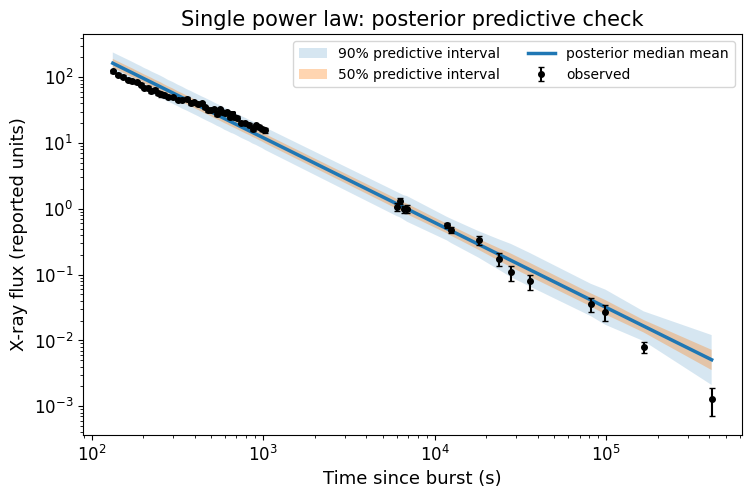

In [31]:
with single_model:
    # posterior predictive checks in one line
    pm.sample_posterior_predictive(
        idata_single, var_names=["y_obs"], random_seed=SEED + 1,
        extend_inferencedata=True,
    )


def stacked_samples(group, name):
    return group[name].stack(sample=("chain", "draw")).transpose("sample", "obs_id").values


def posterior_predictive_plot(idata, title):
    y_rep = stacked_samples(idata.posterior_predictive, "y_obs")
    mu_draws = stacked_samples(idata.posterior, "mu")
    pred50 = np.quantile(y_rep, [0.25, 0.75], axis=0)
    pred90 = np.quantile(y_rep, [0.05, 0.95], axis=0)
    median_mu = np.median(mu_draws, axis=0)
    fig, ax = plt.subplots()
    ax.fill_between(time_s, np.exp(pred90[0]), np.exp(pred90[1]), alpha=0.18, label="90% predictive interval")
    ax.fill_between(time_s, np.exp(pred50[0]), np.exp(pred50[1]), alpha=0.32, label="50% predictive interval")
    ax.plot(time_s, np.exp(median_mu), lw=2.5, label="posterior median mean")
    ax.errorbar(time_s, flux, yerr=flux_err, fmt="o", ms=4, color="black", capsize=2, label="observed")
    ax.set(xscale="log", yscale="log", xlabel="Time since burst (s)",
           ylabel="X-ray flux (reported units)", title=title)
    ax.legend(ncol=2)
    plt.show()
    return median_mu


median_mu_single = posterior_predictive_plot(idata_single, "Single power law: posterior predictive check")


Observations:

- The single power law captures the overall declining trend, and most observations lie within the 90% posterior predictive interval.
- The latest observations fall well below the predictive interval, indicating that the decay steepens at late times and a broken power law may be more appropriate.

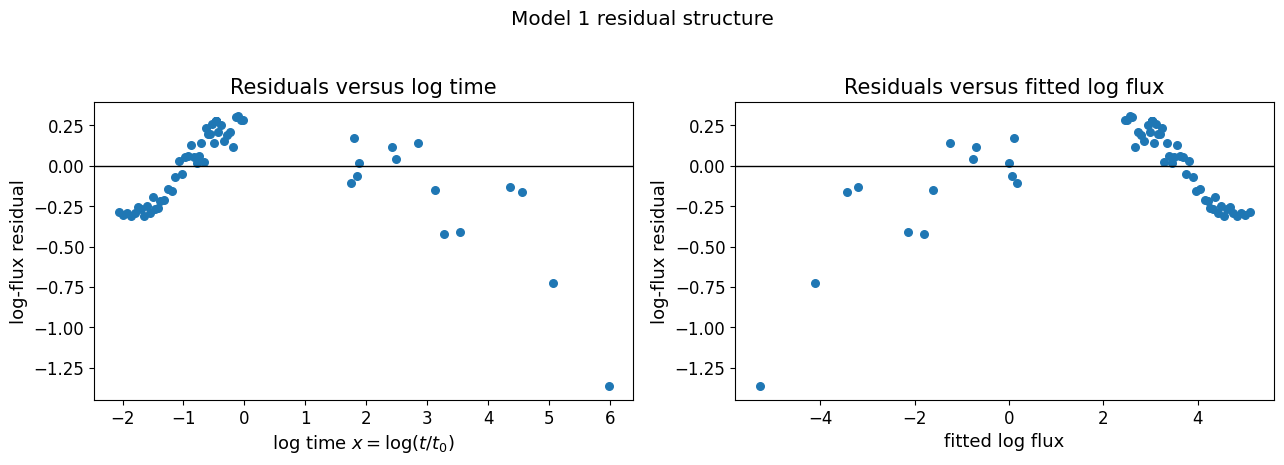

In [32]:
def residual_plots(median_mu, title):
    residual = y - median_mu
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].scatter(x, residual, s=30)
    axes[0].axhline(0, color="black", lw=1)
    axes[0].set(xlabel=r"log time $x=\log(t/t_0)$", ylabel="log-flux residual",
                title="Residuals versus log time")
    axes[1].scatter(median_mu, residual, s=30)
    axes[1].axhline(0, color="black", lw=1)
    axes[1].set(xlabel="fitted log flux", ylabel="log-flux residual",
                title="Residuals versus fitted log flux")
    fig.suptitle(title, y=1.03)
    fig.tight_layout()
    plt.show()


residual_plots(median_mu_single, "Model 1 residual structure")


Observation:

- Early-time residuals move from negative to positive, while late-time residuals become increasingly negative and suggest substantial underprediction of the decay rate, which is consistent with the previous suggestion on a change in decay slope.

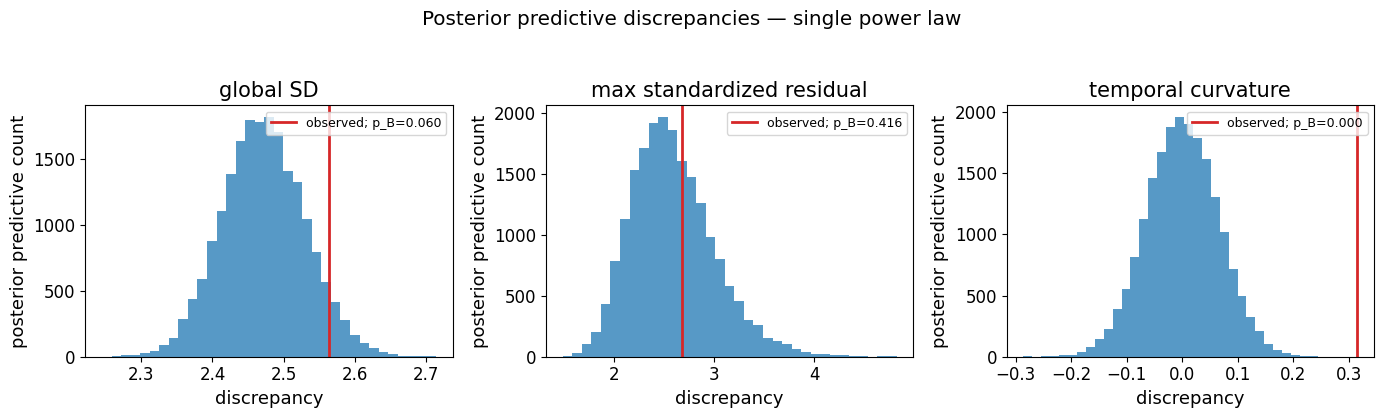

,model,discrepancy,observed reference,tail-area p_B
0,single power law,global SD,2.563437,0.06005
1,single power law,max standardized residual,2.672089,0.41635
2,single power law,temporal curvature,0.315539,0.00000


In [33]:
def ppc_discrepancies(idata, label):
    y_rep = stacked_samples(idata.posterior_predictive, "y_obs")
    mu = stacked_samples(idata.posterior, "mu")
    sigma_int = idata.posterior["sigma_int"].stack(sample=("chain", "draw")).values
    sigma = np.sqrt(y_err[None, :] ** 2 + sigma_int[:, None] ** 2)

    order_groups = np.array_split(np.argsort(x), 3)
    early, middle, late = order_groups
    def curve_stat(residual):
        return (residual[:, middle].mean(axis=1)
                - 0.5 * (residual[:, early].mean(axis=1) + residual[:, late].mean(axis=1)))

    observed_residual = y[None, :] - mu
    replicated_residual = y_rep - mu
    t_obs = {
        "global SD": np.repeat(np.std(y, ddof=1), len(mu)),
        "max standardized residual": np.max(np.abs(observed_residual / sigma), axis=1),
        "temporal curvature": curve_stat(observed_residual),
    }
    t_rep = {
        "global SD": np.std(y_rep, axis=1, ddof=1),
        "max standardized residual": np.max(np.abs(replicated_residual / sigma), axis=1),
        "temporal curvature": curve_stat(replicated_residual),
    }

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    rows = []
    for ax, name in zip(axes, t_rep):
        p_b = float(np.mean(t_rep[name] >= t_obs[name]))
        observed_reference = float(np.mean(t_obs[name]))
        rows.append({"model": label, "discrepancy": name,
                     "observed reference": observed_reference, "tail-area p_B": p_b})
        ax.hist(t_rep[name], bins=35, alpha=0.75)
        ax.axvline(observed_reference, color="C3", lw=2, label=f"observed; p_B={p_b:.3f}")
        ax.set(title=name, xlabel="discrepancy", ylabel="posterior predictive count")
        ax.legend(fontsize=9)
    fig.suptitle(f"Posterior predictive discrepancies — {label}", y=1.04)
    fig.tight_layout()
    plt.show()
    return pd.DataFrame(rows)


ppc_single = ppc_discrepancies(idata_single, "single power law")
display(ppc_single)


Observations:

- The global residual spread is somewhat larger than expected under the model, suggesting mild underestimation of overall variability.
- The maximum standardized residual is consistent with posterior predictions, so isolated extreme residuals are not the main issue.
- Temporal curvature is far outside the predictive distribution, which implies strong evidence that the single power law misses systematic changes in the decay rate.

Note: The posterior predictive tail area $p_B=\Pr[T(y^{\rm rep})\ge T(y)\mid y]$ is a model diagnostic (closer to 0.5 the better), not a classical hypothesis-test p-value. Look for systematic residual curvature and extreme discrepancy values: these can motivate a changing temporal slope even when NUTS diagnostics are excellent.

## 8. Model 2 — continuous broken power law

Keep the break inside the central design range with $u_b\sim\operatorname{Beta}(2,2)$ and
$x_b=x^*_{\min}+u_b(x^*_{\max}-x^*_{\min})$, using the 10th and 90th percentiles. Then

$$
\begin{aligned}
a_b&\sim N(m_a,2^2),& \beta_1&\sim N(-1,0.75^2),\\
\Delta_\beta&\sim N(0,0.75^2),& \beta_2&=\beta_1+\Delta_\beta,\\
\mu_i&=a_b+\beta_1(x_i-x_b)+(\beta_2-\beta_1)\max(0,x_i-x_b).
\end{aligned}
$$

$a_b$ is log flux at the break, $\beta_1$ and $\beta_2$ are early/late slopes, and $t_b=t_0e^{x_b}$. The sign of $\Delta_\beta$ is unconstrained: the data may support steepening or flattening.

In [34]:
X_BREAK_LOWER, X_BREAK_UPPER = np.quantile(x, [0.10, 0.90])


def build_broken_power_law_model(
    x: np.ndarray,
    y: np.ndarray | None,
    y_err: np.ndarray,
    x_break_lower: float,
    x_break_upper: float,
) -> pm.Model:
    coords = {"obs_id": np.arange(len(x))}
    with pm.Model(coords=coords) as model:
        x_data = pm.Data("x", np.asarray(x), dims="obs_id")
        y_err_data = pm.Data("y_err", np.asarray(y_err), dims="obs_id")
        u_b = pm.Beta("u_b", alpha=2, beta=2)
        x_b = pm.Deterministic("x_b", x_break_lower + u_b * (x_break_upper - x_break_lower))
        t_b = pm.Deterministic("t_b", T0 * pm.math.exp(x_b))
        a_b = pm.Normal("a_b", mu=INTERCEPT_PRIOR_MEAN, sigma=2.0)
        beta_1 = pm.Normal("beta_1", mu=-1.0, sigma=0.75)
        delta_beta = pm.Normal("delta_beta", mu=0.0, sigma=0.75)
        beta_2 = pm.Deterministic("beta_2", beta_1 + delta_beta)
        sigma_int = pm.HalfNormal("sigma_int", sigma=0.5)
        dx = x_data - x_b
        mu = pm.Deterministic(
            "mu", a_b + beta_1 * dx + (beta_2 - beta_1) * pm.math.maximum(0.0, dx),
            dims="obs_id",
        )
        sigma_total = pm.Deterministic(
            "sigma_total", pm.math.sqrt(y_err_data**2 + sigma_int**2), dims="obs_id"
        )
        pm.Normal("y_obs", mu=mu, sigma=sigma_total, observed=y, dims="obs_id")
    return model


broken_prior_model = build_broken_power_law_model(
    x, None, y_err, X_BREAK_LOWER, X_BREAK_UPPER
)
with broken_prior_model:
    prior_broken = pm.sample_prior_predictive(draws=300, random_seed=SEED + 2)


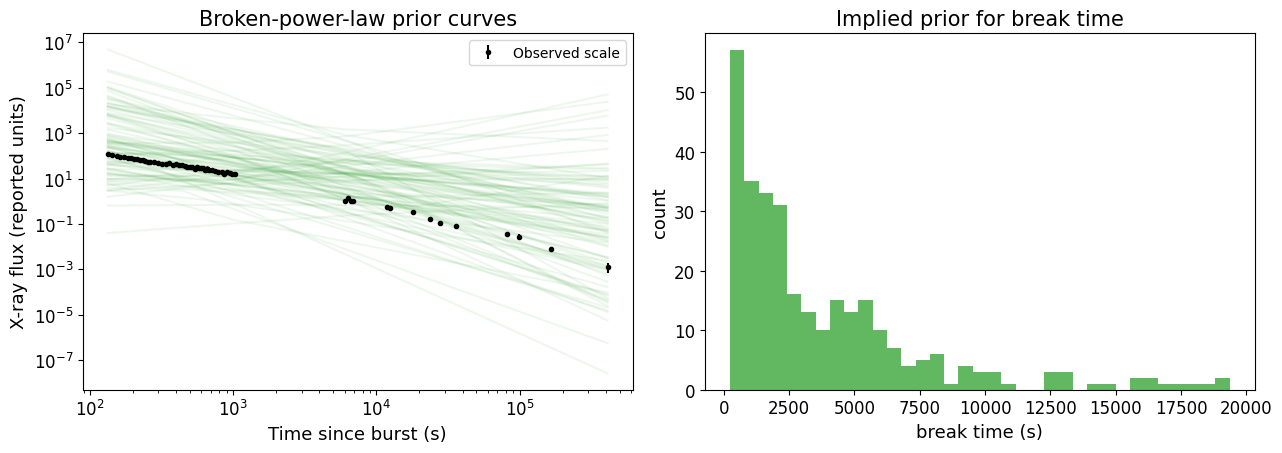

In [35]:
broken_mu = stacked_samples(prior_broken.prior, "mu")
broken_tb = prior_broken.prior["t_b"].values.ravel()
ids = rng.choice(len(broken_mu), 100, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
for j in ids:
    axes[0].plot(time_s, np.exp(broken_mu[j]), color="C2", alpha=0.08)
axes[0].errorbar(time_s, flux, yerr=flux_err, fmt="o", ms=3, color="black", label="Observed scale")
axes[0].set(xscale="log", yscale="log", xlabel="Time since burst (s)",
            ylabel="X-ray flux (reported units)", title="Broken-power-law prior curves")
axes[0].legend()
axes[1].hist(broken_tb, bins=35, alpha=0.75, color="C2")
axes[1].set(xlabel="break time (s)", ylabel="count", title="Implied prior for break time")
fig.tight_layout()
plt.show()


In [36]:
broken_model = build_broken_power_law_model(
    x, y, y_err, X_BREAK_LOWER, X_BREAK_UPPER
)
start = perf_counter()
with broken_model:
    idata_broken = pm.sample(
        draws=draws, tune=tune, chains=4, cores=cores,
        nuts_sampler="nutpie", backend="numba",
        nuts={"target_accept": 0.95}, random_seed=SEED + 3,
    )
    pm.compute_log_likelihood(idata_broken, extend_inferencedata=True)
elapsed_broken = perf_counter() - start
print(f"Elapsed sampling time: {elapsed_broken:.1f} s")
display(az.summary(
    idata_broken,
    var_names=["beta_1", "beta_2", "delta_beta", "t_b", "sigma_int"],
    round_to=3,
))


Progress,Draws,Divergences,Step Size,Gradients/Draw
,10000,0,0.13,127
,10000,0,0.13,15
,10000,0,0.13,11
,10000,0,0.11,31


Output()

Elapsed sampling time: 23.0 s


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_1,-0.925,0.023,-0.964,-0.879,0.000,0.00,2638.235,3120.991,1.001
beta_2,-1.457,0.049,-1.542,-1.373,0.001,0.00,1866.308,4547.366,1.001
delta_beta,-0.532,0.045,-0.617,-0.455,0.001,0.00,3015.095,5270.013,1.001
t_b,1101.061,295.321,650.536,1603.692,7.331,3.32,1582.855,3409.263,1.002
sigma_int,0.030,0.015,0.000,0.053,0.000,0.00,4955.715,3197.721,1.001


In [37]:
diag_broken = az.summary(
    idata_broken,
    var_names=["beta_1", "beta_2", "delta_beta", "t_b", "sigma_int"],
    kind="diagnostics", round_to=3,
)
divergences_broken = int(idata_broken.sample_stats["diverging"].sum().item())
diagnostic_table = pd.DataFrame({
    "model": ["single power law", "broken power law"],
    "divergences": [divergences_single, divergences_broken],
    "max R-hat": [diag_single["r_hat"].max(), diag_broken["r_hat"].max()],
    "min bulk ESS": [diag_single["ess_bulk"].min(), diag_broken["ess_bulk"].min()],
    "min tail ESS": [diag_single["ess_tail"].min(), diag_broken["ess_tail"].min()],
})
display(diagnostic_table)
if divergences_broken or diag_broken["r_hat"].max() >= 1.01:
    print("WARNING: broken-model diagnostics merit investigation; showing traces.")
    az.plot_trace(idata_broken, var_names=["beta_1", "beta_2", "delta_beta", "t_b", "sigma_int"])
    plt.tight_layout()
    plt.show()


,model,divergences,max R-hat,min bulk ESS,min tail ESS
0,single power law,0,1.000,15956.480,13395.852
1,broken power law,0,1.002,1582.855,3120.991


Output()

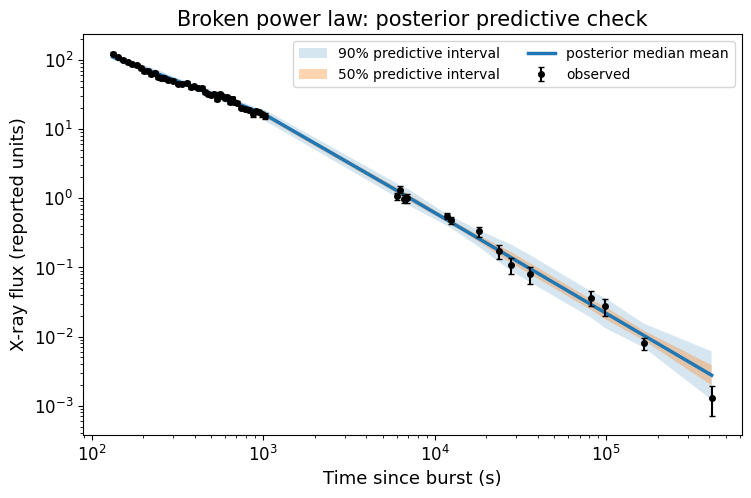

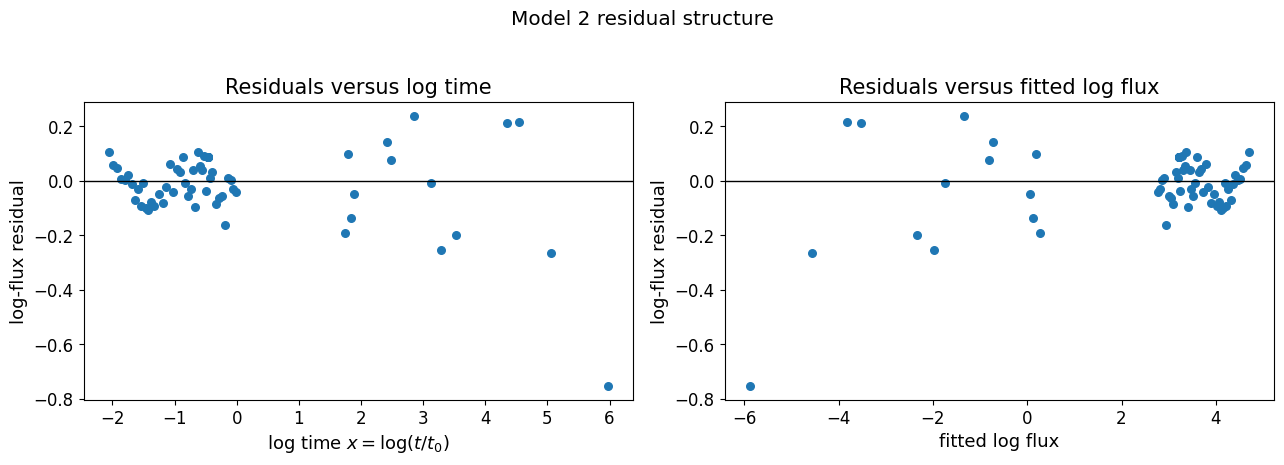

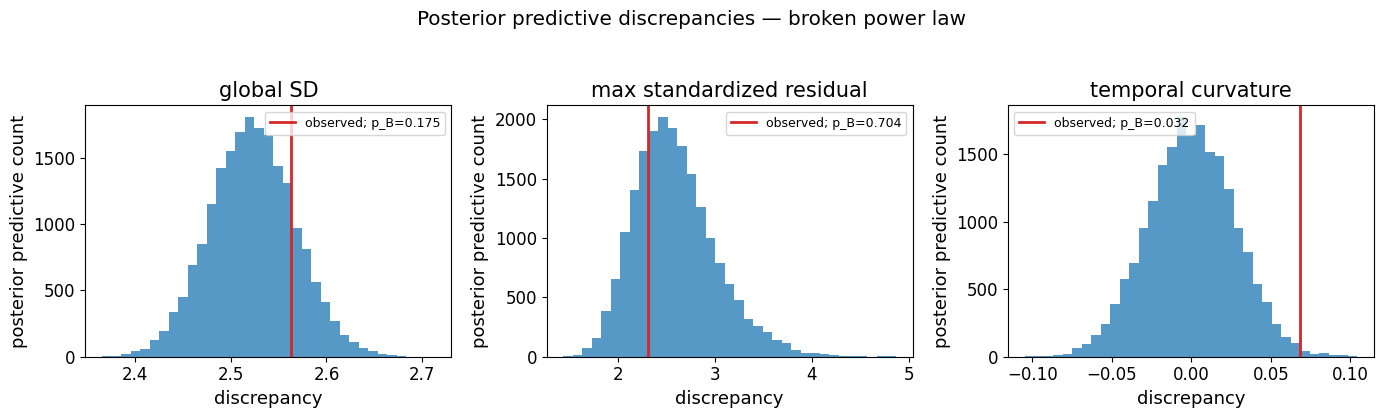

,model,discrepancy,observed reference,tail-area p_B
0,single power law,global SD,2.563437,0.06005
1,single power law,max standardized residual,2.672089,0.41635
2,single power law,temporal curvature,0.315539,0.00000
3,broken power law,global SD,2.563437,0.17525
4,broken power law,max standardized residual,2.311093,0.70415
5,broken power law,temporal curvature,0.068503,0.03235


In [38]:
with broken_model:
    pm.sample_posterior_predictive(
        idata_broken, var_names=["y_obs"], random_seed=SEED + 4,
        extend_inferencedata=True,
    )
median_mu_broken = posterior_predictive_plot(idata_broken, "Broken power law: posterior predictive check")
residual_plots(median_mu_broken, "Model 2 residual structure")
ppc_broken = ppc_discrepancies(idata_broken, "broken power law")
display(pd.concat([ppc_single, ppc_broken], ignore_index=True))


## 9. Model evalution with predictive information criteria and PSIS-LOO

- Goal: compare models by their expected out-of-sample predictive accuracy instead of in-sample fit, which is summarized by the expected log predictive density (ELPD); larger ELPD = better.
- Exact LOO-CV: leave out observation $i$, refit the model to $y_{-i}$, evaluate the predictive density of $y_i$, and sum over $i=1,...,n$;
    - Con: No one wants to fit the model $n$ times; computationally infeasible when $n$ is large.
- WAIC: approximates LOO from one posterior fit using the pointwise log-likelihood and an effective-complexity correction;
    - asymptotically equivalent to LOO but can be less reliable with finite samples or influential observations.
- PSIS-LOO: approximates exact LOO from the full-data posterior draws, avoiding n separate refits using Pareto-smoothed importance sampling (PSIS)
    - Pareto-$\hat{k}$ diagnostic: measures how reliable the PSIS approximation is for each observation; 
    - Rule-of-thumb: $\hat{k} \leq 0.5$ is deemed reliable, $0.5\leq \hat{k} \leq 0.7$ usually acceptable.
- Model comparison: report $\Delta ELPD = ELPD_A - ELPD_B$ with their standard errors.
    - $\Delta ELPD > 0$ favors model A, but differences small relative to their standard errors are inconclusive.


Note that a better score does not prove a physical mechanism.

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
broken power law,0,59.200748,6.543195,0.000000,1.0,5.960820,0.000000,False,log
single power law,1,-4.394488,3.444393,63.595236,0.0,5.992115,5.926276,False,log


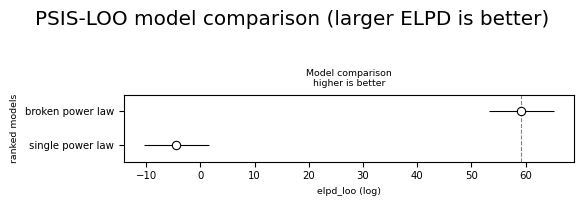

In [39]:
# The sampling calls requested pointwise log likelihood. Compute it only if an
# installed PyMC version did not attach it during conversion.
if not hasattr(idata_single, "log_likelihood"):
    with single_model:
        pm.compute_log_likelihood(idata_single, extend_inferencedata=True)
if not hasattr(idata_broken, "log_likelihood"):
    with broken_model:
        pm.compute_log_likelihood(idata_broken, extend_inferencedata=True)

loo_single = az.loo(idata_single, pointwise=True)
loo_broken = az.loo(idata_broken, pointwise=True)
comparison = az.compare(
    {"single power law": idata_single, "broken power law": idata_broken},
    # ArviZ 1.2 compare() is PSIS-LOO-specific; the older ic="loo" argument was removed.
    method="stacking",
)
display(comparison)

az.plot_compare(comparison)
plt.gcf().suptitle("PSIS-LOO model comparison (larger ELPD is better)", y=1.02)
plt.tight_layout()
plt.show()


In [40]:
def influential_observations(loo_result, model_name, n=5):
    pareto_k = np.asarray(loo_result.pareto_k)
    idx = np.argsort(pareto_k)[-n:][::-1]
    return pd.DataFrame({
        "model": model_name,
        "obs_id": idx,
        "time_s": time_s[idx],
        "flux": flux[idx],
        "pareto_k": pareto_k[idx],
        "log_residual_at_posterior_mean": (y - (median_mu_single if model_name.startswith("single") else median_mu_broken))[idx],
    })


influence = pd.concat([
    influential_observations(loo_single, "single power law"),
    influential_observations(loo_broken, "broken power law"),
], ignore_index=True)
display(influence)
print("Pareto-k counts by model and threshold:")
display(pd.DataFrame({
    "model": ["single power law", "broken power law"],
    "k > 0.7": [int((np.asarray(loo_single.pareto_k) > 0.7).sum()), int((np.asarray(loo_broken.pareto_k) > 0.7).sum())],
    "k > 1.0": [int((np.asarray(loo_single.pareto_k) > 1.0).sum()), int((np.asarray(loo_broken.pareto_k) > 1.0).sum())],
}))


,model,obs_id,time_s,flux,pareto_k,log_residual_at_posterior_mean
0,single power law,61,165485.0,0.0080,0.532793,-0.725830
1,single power law,62,412515.0,0.0013,0.306155,-1.363786
2,single power law,58,35859.0,0.0790,0.195902,-0.409138
3,single power law,57,27859.0,0.1080,0.194081,-0.422279
4,single power law,59,81459.0,0.0361,0.191392,-0.133606
5,broken power law,0,133.0,122.7000,0.464781,0.105915
6,broken power law,61,165485.0,0.0080,0.395656,-0.264752
7,broken power law,49,6009.0,1.0720,0.369640,-0.191096
8,broken power law,53,11809.0,0.5600,0.329827,0.140873
9,broken power law,51,6609.0,0.9870,0.298442,-0.135283


Pareto-k counts by model and threshold:


,model,k > 0.7,k > 1.0
0,single power law,0,0
1,broken power law,0,0


High Pareto-$k$ values flag observations for which the PSIS approximation may be unreliable. Compare their times with residual plots: they may be flare-like or simply unusual, but the table alone does not justify an astrophysical interpretation. Predictive criteria complement rather than replace posterior predictive criticism.

<details><summary><b>Optional after the tutorial — WAIC</b></summary>

PSIS-LOO is primary because Pareto-$k$ supplies observation-level influence diagnostics. WAIC is included only as a secondary sensitivity check.
</details>


In [41]:
def waic_from_log_likelihood(idata, observed_name="y_obs"):
    """Current ArviZ no longer exposes az.waic; compute standard pointwise WAIC."""
    log_lik = stacked_samples(idata.log_likelihood, observed_name)
    lppd_i = scipy.special.logsumexp(log_lik, axis=0) - np.log(log_lik.shape[0])
    p_waic_i = np.var(log_lik, axis=0, ddof=1)
    elpd_i = lppd_i - p_waic_i
    return {
        "elpd_waic": float(elpd_i.sum()),
        "p_waic": float(p_waic_i.sum()),
        "SE": float(np.sqrt(len(elpd_i) * np.var(elpd_i, ddof=1))),
        "points with Var(log likelihood) > 0.4": int((p_waic_i > 0.4).sum()),
    }


display(pd.DataFrame([
    {"model": "single power law", **waic_from_log_likelihood(idata_single)},
    {"model": "broken power law", **waic_from_log_likelihood(idata_broken)},
]).set_index("model"))


,elpd_waic,p_waic,SE,points with Var(log likelihood) > 0.4
model,,,,
single power law,-4.336607,3.386512,6.008622,2
broken power law,59.341404,6.402539,5.984100,4


## Optional — robust broken power law

The broken power law changes the **mean**; a Student-$t$ likelihood changes the **residual distribution**. With $\nu=2+\nu_{\rm raw}$ and $\nu_{\rm raw}\sim\operatorname{Exponential}(1/10)$, robustness can reduce the influence of flare-like observations. Heavy tails are not a physical flare model.


In [42]:
def build_robust_broken_power_law_model(
    x: np.ndarray,
    y: np.ndarray | None,
    y_err: np.ndarray,
    x_break_lower: float,
    x_break_upper: float,
) -> pm.Model:
    coords = {"obs_id": np.arange(len(x))}
    with pm.Model(coords=coords) as model:
        x_data = pm.Data("x", np.asarray(x), dims="obs_id")
        y_err_data = pm.Data("y_err", np.asarray(y_err), dims="obs_id")
        u_b = pm.Beta("u_b", 2, 2)
        x_b = pm.Deterministic("x_b", x_break_lower + u_b * (x_break_upper - x_break_lower))
        t_b = pm.Deterministic("t_b", T0 * pm.math.exp(x_b))
        a_b = pm.Normal("a_b", INTERCEPT_PRIOR_MEAN, 2)
        beta_1 = pm.Normal("beta_1", -1, 0.75)
        delta_beta = pm.Normal("delta_beta", 0, 0.75)
        beta_2 = pm.Deterministic("beta_2", beta_1 + delta_beta)
        sigma_int = pm.HalfNormal("sigma_int", 0.5)
        nu_raw = pm.Exponential("nu_raw", lam=0.1)
        nu = pm.Deterministic("nu", 2 + nu_raw)
        dx = x_data - x_b
        mu = pm.Deterministic(
            "mu", a_b + beta_1 * dx + (beta_2 - beta_1) * pm.math.maximum(0, dx), dims="obs_id"
        )
        sigma = pm.math.sqrt(y_err_data**2 + sigma_int**2)
        pm.StudentT("y_obs", nu=nu, mu=mu, sigma=sigma, observed=y, dims="obs_id")
    return model


RUN_ROBUST = True
if RUN_ROBUST:
    robust_model = build_robust_broken_power_law_model(x, y, y_err, X_BREAK_LOWER, X_BREAK_UPPER)
    with robust_model:
        idata_robust = pm.sample(
            draws=draws, tune=tune, chains=4, cores=cores,
            nuts_sampler="nutpie", backend="numba", nuts={"target_accept": 0.9},
            random_seed=SEED + 5,
        )
        pm.compute_log_likelihood(idata_robust, extend_inferencedata=True)
        pm.sample_posterior_predictive(
            idata_robust, random_seed=SEED + 6, extend_inferencedata=True
        )
    display(az.compare({
        "single": idata_single, "broken": idata_broken, "robust broken": idata_robust
    }, method="stacking"))
else:
    print("Robust model defined but not fit. Set RUN_ROBUST=True after the live tutorial.")


Progress,Draws,Divergences,Step Size,Gradients/Draw
,10000,0,0.16,15
,10000,0,0.16,127
,10000,0,0.17,95
,10000,0,0.15,15


Output()

Output()

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
broken,0,59.200748,6.543195,0.000000,1.000000e+00,5.960820,0.000000,False,log
robust broken,1,58.323234,6.386006,0.877514,0.000000e+00,5.864923,0.263721,False,log
single,2,-4.394488,3.444393,63.595236,6.212253e-13,5.992115,5.926276,False,log


## 10. Summary

Mental workflow steps:

1. Start from a generative model (prior + likelihood).
2. Use prior predictive checks to identify implausibility before conditioning on observations.
3. Use SBC to validate implementation and inference under the assumed model.
4. Check NUTS computation diagnostics after sampling.
5. Use posterior predictive checks to identify in-sample fit failures.
6. Revise specific model choices and assumptions in response.
7. Compare predictive performance with uncertainty and diagnostics. Distinguish statistically meaningful from physically meaningful.


## References

- Penn State Center for Astrostatistics, [Gamma-ray burst afterglow modelling and `GRB_afterglow.dat`](https://sites.psu.edu/astrostatistics/datasets-grb-afterglow/).
- Blustin et al. (2006), [*Swift panchromatic observations of the bright gamma-ray burst GRB 050525a*](https://arxiv.org/abs/astro-ph/0507515), *ApJ* 637, 901–913.
- [PyMC documentation](https://www.pymc.io/projects/docs/en/stable/).
- [nutpie documentation](https://pymc-devs.github.io/nutpie/).
- [ArviZ documentation](https://python.arviz.org/).
- Talts et al. (2018), [*Validating Bayesian Inference Algorithms with Simulation-Based Calibration*](https://arxiv.org/abs/1804.06788).
- Vehtari, Gelman, and Gabry (2017), [*Practical Bayesian model evaluation using leave-one-out cross-validation and WAIC*](https://doi.org/10.1007/s11222-016-9696-4).

The source page attributes the table to Swift XRT observations and notes the original analysis. The present notebook is a pedagogical reanalysis; it does not reproduce the paper's full physical model.
